
# **IT3012 WEEK 7 Practical**

## Fuzzy Inference Systems

In this practical, you will construct and evaluate a fuzzy controller for an autonomous cleaning robot.

The system takes environmental sensor inputs (dirt level and surface type) and determines appropriate cleaning behaviour (intensity and duration). Through this exercise, you will explore how fuzzy rules combine to produce adaptive decisions in uncertain environments.


By the end of this session, you will have built a complete fuzzy logic controller that:
- takes sensor inputs (dirt level, surface type)
- makes intelligent decisions (cleaning intensity, cleaning duration)
- handles competing objectives (gentle vs effective cleaning)
- behaves like a human expert would

### Setup: Import Libraries

First, let's set up our environment with the same `skfuzzy` tools from Week 5.



In [1]:
!pip install scikit-fuzzy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 37.5 MB/s eta 0:00:00


> May need to restart the session

In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

print(f"✓ scikit-fuzzy version: {fuzz.__version__}")
print(f"✓ NumPy version: {np.__version__}")
print("✓ Ready to build fuzzy inference systems!")

✓ scikit-fuzzy version: 0.5.0
✓ NumPy version: 2.1.3
✓ Ready to build fuzzy inference systems!


### [Activity 1] Building the Fuzzy Inference System

A complete fuzzy inference system has several components:

```
1. INPUTS (Antecedents) (week 5)
   ↓
2. FUZZIFICATION (convert crisp input to fuzzy) (week 5)
   ↓
3. RULE BASE (IF-THEN rules)
   ↓
4. INFERENCE ENGINE (combine rules)
   ↓
5. AGGREGATION (merge all outputs)
   ↓
6. DEFUZZIFICATION (convert fuzzy output to crisp)
   ↓
7. OUTPUTS (Consequents)
```

Let's build this step by step using scikit-fuzzy's `control` module!


Step 1.1: Define the Input and Output Variables (Code are given)

In scikit-fuzzy, we use:
- `ctrl.Antecedent()` for inputs
- `ctrl.Consequent()` for outputs

These are more powerful than the basic fuzzy sets from Week 5 - they're designed specifically for control systems.

In [3]:
# Define the universe of discourse for each variable
# These are the possible values each variable can take

# INPUT 1: Dirt Level (0% to 100%)
dirt_level = ctrl.Antecedent(np.arange(0, 101, 1), 'dirt_level')

# INPUT 2: Surface Type (0 = delicate, 100 = hard floor)
surface_type = ctrl.Antecedent(np.arange(0, 101, 1), 'surface_type')

# OUTPUT 1: Cleaning Intensity (0% to 100%)
cleaning_intensity = ctrl.Consequent(np.arange(0, 101, 1), 'cleaning_intensity')

# OUTPUT 2: Cleaning Duration (0% to 100%)
cleaning_duration = ctrl.Consequent(np.arange(0, 101, 1), 'cleaning_duration')

print("✓ Variables defined!")
print(f"  Inputs: {dirt_level.label}, {surface_type.label}")
print(f"  Outputs: {cleaning_intensity.label}, {cleaning_duration.label}")

✓ Variables defined!
  Inputs: dirt_level, surface_type
  Outputs: cleaning_intensity, cleaning_duration


TODO

Step 1.2: Define Membership Functions. You are required to add membership functions to each variable:

* 1. DIRT LEVEL membership functions [low, medium, high] (Keep the design philosophy from Week 5.)
- 2. SURFACE TYPE membership functions [delicate, carpet, hard_floor] (Keep the design philosophy from Week 5.)
- 3. CLEANING INTENSITY membership functions [gentle, normal, aggressive] (New from this week 6)
- 4. CLEANING DURATION membership functions [quick, standard, extended] (New from this week 6)

In [4]:

# DIRT LEVEL membership functions


dirt_level['low'] = fuzz.trimf(
    dirt_level.universe,
    [0, 0, 50]
)

dirt_level['medium'] = fuzz.trimf(
    dirt_level.universe,
    [0, 50, 100]
)

dirt_level['high'] = fuzz.trimf(
    dirt_level.universe,
    [50, 100, 100]
)



# SURFACE TYPE membership functions


surface_type['delicate'] = fuzz.trimf(
    surface_type.universe,
    [0, 0, 50]
)

surface_type['carpet'] = fuzz.trimf(
    surface_type.universe,
    [0, 50, 100]
)

surface_type['hard_floor'] = fuzz.trimf(
    surface_type.universe,
    [50, 100, 100]
)



# CLEANING INTENSITY membership functions


cleaning_intensity['gentle'] = fuzz.trimf(
    cleaning_intensity.universe,
    [0, 0, 50]
)

cleaning_intensity['normal'] = fuzz.trimf(
    cleaning_intensity.universe,
    [0, 50, 100]
)

cleaning_intensity['aggressive'] = fuzz.trimf(
    cleaning_intensity.universe,
    [50, 100, 100]
)



# CLEANING DURATION membership functions


cleaning_duration['quick'] = fuzz.trimf(
    cleaning_duration.universe,
    [0, 0, 50]
)

cleaning_duration['standard'] = fuzz.trimf(
    cleaning_duration.universe,
    [0, 50, 100]
)

cleaning_duration['extended'] = fuzz.trimf(
    cleaning_duration.universe,
    [50, 100, 100]
)

print("✓ Membership functions created!")

✓ Membership functions created!


Step 1.3: Execute the given code to visualise the membership functions. Observe the shape and overlap of the fuzzy sets, and explain how your design reflects the linguistic descriptions of the variables.

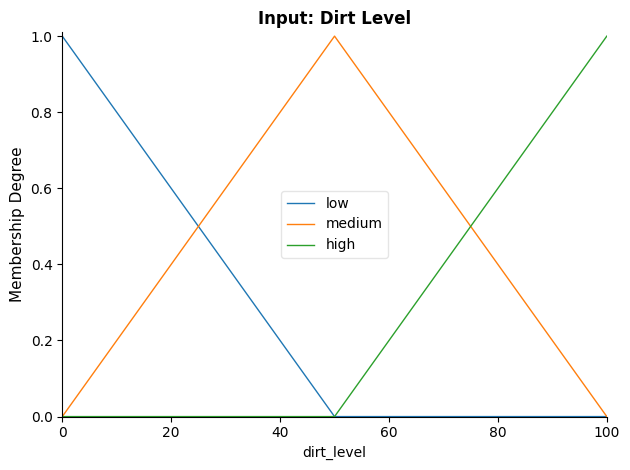

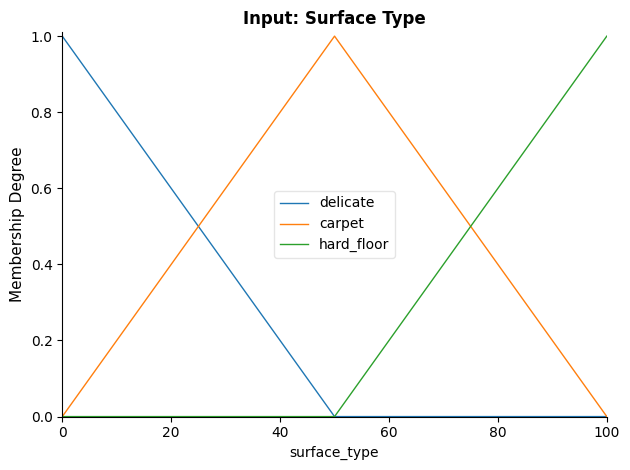

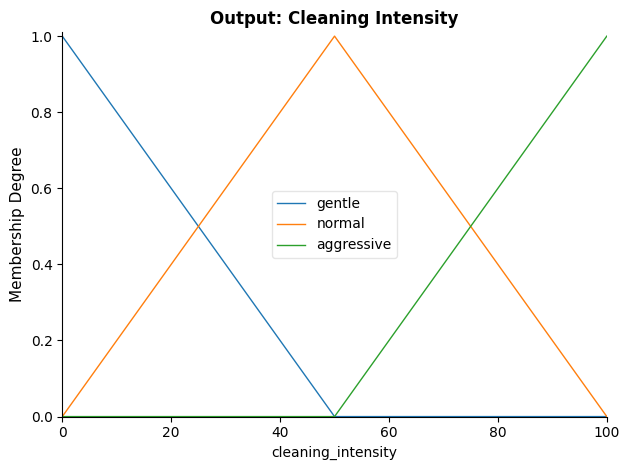

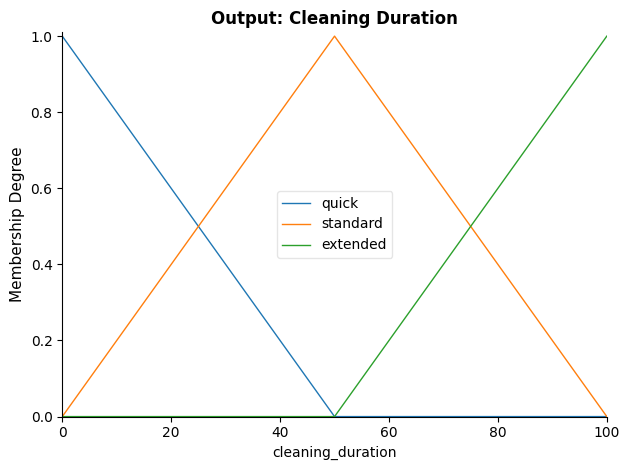

In [5]:
# Visualise all membership functions

# Figure 1: Input - Dirt Level
dirt_level.view()
plt.title('Input: Dirt Level', fontweight='bold', fontsize=12)
plt.ylabel('Membership Degree', fontsize=11)
plt.tight_layout()
plt.show()

# Figure 2: Input - Surface Type
surface_type.view()
plt.title('Input: Surface Type', fontweight='bold', fontsize=12)
plt.ylabel('Membership Degree', fontsize=11)
plt.tight_layout()
plt.show()

# Figure 3: Output - Cleaning Intensity
cleaning_intensity.view()
plt.title('Output: Cleaning Intensity', fontweight='bold', fontsize=12)
plt.ylabel('Membership Degree', fontsize=11)
plt.tight_layout()
plt.show()

# Figure 4: Output - Cleaning Duration
cleaning_duration.view()
plt.title('Output: Cleaning Duration', fontweight='bold', fontsize=12)
plt.ylabel('Membership Degree', fontsize=11)
plt.tight_layout()
plt.show()


TODO

Step 1.4: With 2 inputs (dirt: 3 levels, surface: 3 types), we have **3 × 3 = 9 possible combinations**. For each cell, decide what cleaning intensity makes sense. (We discussed it in Lecture, you may use the discussed outcome, or you can re-design it)

Sample Rule Matrix - Layout, CLEANING INTENSITY
| Dirt \ Surface | Delicate | Carpet  | Hard Floor  |
|----------------|----------|---------|-------------|
| **Low**        | Gentle       | Gentle       | Normal          |
| **Medium**     | Gentle        | Normal      | Normal       |
| **High**       | Normal       | Aggressive      | Aggressive           |


Sample Rule Matrix - CLEANING DURATION RULES

| Dirt \ Surface | Delicate | Carpet  | Hard Floor  |
|----------------|----------|---------|-------------|
| **Low**        | Quick       | Quick       | Quick          |
| **Medium**     | Standard        | Standard      | Quick       |
| **High**       | Extended       | Extended      | Standard           |




The rule base represents expert knowledge about how the cleaning robot should behave in different situations.

Each rule links environmental conditions (dirt level and surface type) to appropriate cleaning actions. When multiple rules are activated simultaneously, the fuzzy inference system combines their effects to determine the final output behaviour.

TODO

Step 1.5: Implementing all the Rules based on your Rule Matrix into code.



```
# Given the implementation of row 1:
# Row 1: Low Dirt
rule1 = ctrl.Rule(dirt_level['low'] & surface_type['delicate'], cleaning_intensity['gentle'])
rule2 = ctrl.Rule(dirt_level['low'] & surface_type['carpet'], cleaning_intensity['gentle'])
rule3 = ctrl.Rule(dirt_level['low'] & surface_type['hard_floor'], cleaning_intensity['normal'])
```



In [6]:

# CLEANING INTENSITY RULES

# Row 1: Low Dirt
rule1 = ctrl.Rule(
    dirt_level['low'] & surface_type['delicate'],
    cleaning_intensity['gentle']
)

rule2 = ctrl.Rule(
    dirt_level['low'] & surface_type['carpet'],
    cleaning_intensity['gentle']
)

rule3 = ctrl.Rule(
    dirt_level['low'] & surface_type['hard_floor'],
    cleaning_intensity['normal']
)


# Row 2: Medium Dirt
rule4 = ctrl.Rule(
    dirt_level['medium'] & surface_type['delicate'],
    cleaning_intensity['gentle']
)

rule5 = ctrl.Rule(
    dirt_level['medium'] & surface_type['carpet'],
    cleaning_intensity['normal']
)

rule6 = ctrl.Rule(
    dirt_level['medium'] & surface_type['hard_floor'],
    cleaning_intensity['normal']
)


# Row 3: High Dirt
rule7 = ctrl.Rule(
    dirt_level['high'] & surface_type['delicate'],
    cleaning_intensity['normal']
)

rule8 = ctrl.Rule(
    dirt_level['high'] & surface_type['carpet'],
    cleaning_intensity['aggressive']
)

rule9 = ctrl.Rule(
    dirt_level['high'] & surface_type['hard_floor'],
    cleaning_intensity['aggressive']
)

In [7]:

# CLEANING DURATION RULES

# Row 1: Low Dirt
rule10 = ctrl.Rule(
    dirt_level['low'] & surface_type['delicate'],
    cleaning_duration['quick']
)

rule11 = ctrl.Rule(
    dirt_level['low'] & surface_type['carpet'],
    cleaning_duration['quick']
)

rule12 = ctrl.Rule(
    dirt_level['low'] & surface_type['hard_floor'],
    cleaning_duration['quick']
)


# Row 2: Medium Dirt
rule13 = ctrl.Rule(
    dirt_level['medium'] & surface_type['delicate'],
    cleaning_duration['standard']
)

rule14 = ctrl.Rule(
    dirt_level['medium'] & surface_type['carpet'],
    cleaning_duration['standard']
)

rule15 = ctrl.Rule(
    dirt_level['medium'] & surface_type['hard_floor'],
    cleaning_duration['quick']
)


# Row 3: High Dirt
rule16 = ctrl.Rule(
    dirt_level['high'] & surface_type['delicate'],
    cleaning_duration['extended']
)

rule17 = ctrl.Rule(
    dirt_level['high'] & surface_type['carpet'],
    cleaning_duration['extended']
)

rule18 = ctrl.Rule(
    dirt_level['high'] & surface_type['hard_floor'],
    cleaning_duration['standard']
)

print("✓ All 18 fuzzy rules created!")

✓ All 18 fuzzy rules created!


TODO

Step 1.6: Execute the given code to create the control systems. Now we combine our rules into control systems. We'll create two separate systems since we have two outputs.

In [8]:
# Control System for Cleaning Intensity
intensity_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3,
    rule4, rule5, rule6,
    rule7, rule8, rule9
])

# Control System for Cleaning Duration
duration_ctrl = ctrl.ControlSystem([
    rule10, rule11, rule12,
    rule13, rule14, rule15,
    rule16, rule17, rule18
])

# Create simulation objects
intensity_sim = ctrl.ControlSystemSimulation(intensity_ctrl)
duration_sim = ctrl.ControlSystemSimulation(duration_ctrl)

### [Activity 2] Testing the Fuzzy Inference System

Let's see our fuzzy controller in action!

The commands `intensity_sim.compute()` and `duration_sim.compute()` run the fuzzy inference process

They perform steps automatically:
* fuzzification
* activates the fuzzy rules
* aggregation
* defuzzification

The resulting crisp value can then be accessed using commands:
* `intensity_sim.output['cleaning_intensity']`
* `duration_sim.output['cleaning_duration']`


TODO

Task 2.1: Execute the given code and identify the Centroid value. Then address the following questions.

* 1. What does the centroid value represent in the fuzzy inference system output?
* 2. How do the overlapping membership functions (gentle, normal, aggressive) influence the final centroid value?
* 3. If the input values (dirt_level or surface_type) change, how would you expect the centroid output to change? Explain your reasoning.

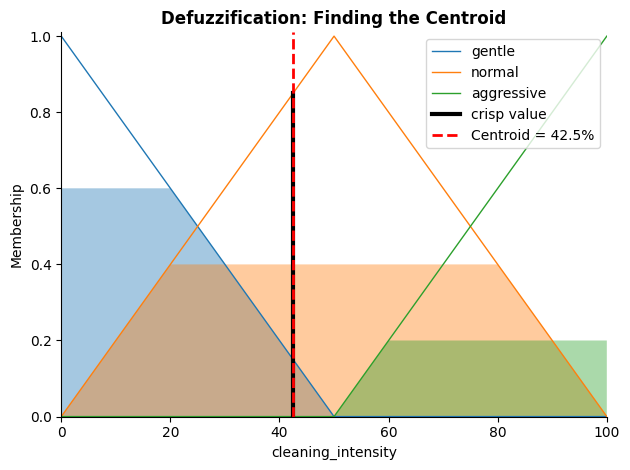

In [9]:
# Demonstrating the defuzzification process visually

# Set up the inputs
intensity_sim.input['dirt_level'] = 60
intensity_sim.input['surface_type'] = 20

# Compute
intensity_sim.compute()

# View the aggregated output and defuzzification
cleaning_intensity.view(sim=intensity_sim)
plt.title('Defuzzification: Finding the Centroid', fontweight='bold')
plt.axvline(x=intensity_sim.output['cleaning_intensity'],
            color='red', linestyle='--', linewidth=2,
            label=f"Centroid = {intensity_sim.output['cleaning_intensity']:.1f}%")
plt.legend()
plt.tight_layout()
plt.show()


Q1. What does centroid represent?
- The centroid is the crisp numerical output produced after defuzzification. It represents the final recommended cleaning intensity after combining all activated fuzzy rules.

Q2. How do overlapping memberships affect it?
- Overlapping membership functions allow multiple rules to activate at the same time. Their outputs are combined, so the centroid becomes a balanced value between gentle, normal and aggressive cleaning rather than selecting only one category.

Q3. What happens when inputs change?
- When dirt level or surface type changes, different membership functions and fuzzy rules become activated with different strengths. Therefore, the centroid moves smoothly toward the cleaning behaviour most suitable for the new conditions.

TODO

Task 2.2: Conduct a test for the following scenario:

```
Test 1: The Delicate Dilemma
Scenario: Laboratory with sensitive equipment

- Dirt Level: 80% (very dirty!)
- Surface Type: 10 (very delicate)
```

You are given a sample code to configure the test case for `Test 1: The Delicate Dilemma`. Study the code sample, execute it, and explain the fuzzy behaviour.




In [10]:
# Test Case 1: High dirt, delicate surface
test_dirt = 80
test_surface = 10

# Set inputs for intensity system
intensity_sim.input['dirt_level'] = test_dirt
intensity_sim.input['surface_type'] = test_surface

# Set inputs for duration system
duration_sim.input['dirt_level'] = test_dirt
duration_sim.input['surface_type'] = test_surface

# Compute the results
intensity_sim.compute()
duration_sim.compute()

# Get the outputs
result_intensity = intensity_sim.output['cleaning_intensity']
result_duration = duration_sim.output['cleaning_duration']

print("="*60)
print("TEST 1: Laboratory - High Dirt, Delicate Surface")
print("="*60)
print(f"\nInputs:")
print(f"  Dirt Level: {test_dirt}%")
print(f"  Surface Type: {test_surface} (very delicate)")
print(f"\nOutputs:")
print(f"  Cleaning Intensity: {result_intensity:.1f}%")
print(f"  Cleaning Duration: {result_duration:.1f}%")

TEST 1: Laboratory - High Dirt, Delicate Surface

Inputs:
  Dirt Level: 80%
  Surface Type: 10 (very delicate)

Outputs:
  Cleaning Intensity: 47.3%
  Cleaning Duration: 58.8%


Although the dirt level is high, the surface is very delicate. Therefore, the fuzzy system avoids extremely aggressive cleaning. It selects a moderate cleaning intensity while using a longer cleaning duration. This balances effective cleaning with protection of the sensitive surface.

TODO

Task 2.3: Conduct the following test case scenarios respectively

```
Test 2: The Heavy-Duty Challenge
Scenario: Emergency department corridor

- Dirt Level: 80% (same dirt as before!)
- Surface Type: 90 (very durable hard floor)
```

```
Test 3: The Ambiguous Middle
Scenario: Waiting room with carpet

- Dirt Level: 50% (right in the middle)
- Surface Type: 50 (right in the middle)
```

Answer the following questions:

* 1. Compare the outputs of Test 2 and Test 3. How do the input conditions influence the cleaning intensity and duration?

* 2. Which fuzzy membership functions are most likely activated in each test scenario? Explain how these activated rules contribute to the final result.

* 3. What does this experiment show about how fuzzy systems handle uncertain or ambiguous inputs?

In [11]:
# Test Case 2: High dirt, hard floor

test_dirt = 80
test_surface = 90

intensity_sim.input['dirt_level'] = test_dirt
intensity_sim.input['surface_type'] = test_surface

duration_sim.input['dirt_level'] = test_dirt
duration_sim.input['surface_type'] = test_surface

intensity_sim.compute()
duration_sim.compute()

result_intensity = intensity_sim.output['cleaning_intensity']
result_duration = duration_sim.output['cleaning_duration']

print("=" * 60)
print("TEST 2: Emergency Department Corridor")
print("=" * 60)

print(f"Dirt Level: {test_dirt}%")
print(f"Surface Type: {test_surface}")

print(f"Cleaning Intensity: {result_intensity:.1f}%")
print(f"Cleaning Duration: {result_duration:.1f}%")

TEST 2: Emergency Department Corridor
Dirt Level: 80%
Surface Type: 90
Cleaning Intensity: 58.8%
Cleaning Duration: 47.3%


In [12]:
# Test Case 3: Medium dirt, carpet

test_dirt = 50
test_surface = 50

intensity_sim.input['dirt_level'] = test_dirt
intensity_sim.input['surface_type'] = test_surface

duration_sim.input['dirt_level'] = test_dirt
duration_sim.input['surface_type'] = test_surface

intensity_sim.compute()
duration_sim.compute()

result_intensity = intensity_sim.output['cleaning_intensity']
result_duration = duration_sim.output['cleaning_duration']

print("=" * 60)
print("TEST 3: Waiting Room with Carpet")
print("=" * 60)

print(f"Dirt Level: {test_dirt}%")
print(f"Surface Type: {test_surface}")

print(f"Cleaning Intensity: {result_intensity:.1f}%")
print(f"Cleaning Duration: {result_duration:.1f}%")

TEST 3: Waiting Room with Carpet
Dirt Level: 50%
Surface Type: 50
Cleaning Intensity: 50.0%
Cleaning Duration: 50.0%


1. Compare the outputs of Test 2 and Test 3. How do the input conditions influence the cleaning intensity and duration?
- Test 2 has high dirt and a hard floor, so the controller recommends stronger cleaning intensity. The durable surface allows the robot to clean more aggressively. Test 3 contains medium dirt and carpet, so the controller recommends more moderate normal cleaning with a standard duration.

2. Which fuzzy membership functions are most likely activated in each test scenario? Explain how these activated rules contribute to the final result.
- In Test 2, the high dirt and hard-floor membership functions are strongly activated, while nearby medium and carpet memberships may also be partially activated because the fuzzy sets overlap. These rules mainly produce aggressive cleaning and moderate duration. In Test 3, medium dirt and carpet have their maximum membership, so normal cleaning intensity and standard duration dominate the output.

3. What does this experiment show about how fuzzy systems handle uncertain or ambiguous inputs?
- The experiment shows that fuzzy systems can handle uncertain and ambiguous inputs by allowing values to belong partially to multiple fuzzy sets. Instead of making an abrupt yes/no decision, the system combines several rules and generates a smooth final output.

### [Activity 3] Generate the Control Surface

Execute the provided code to generate the control surface plots for the fuzzy cleaning system.


The program will evaluate the fuzzy controller across all combinations of input values for:

* dirt level
* surface type

For each combination, the fuzzy inference system computes:

* cleaning intensity
* cleaning duration

The results are visualised using:

* 3D surface plots to show how outputs vary across the input space
* 2D contour plots show the same data as the 3D surface plots from a top-down view, to help identify patterns and transitions more clearly

Observe how the outputs change as the input values vary across the input space.


TODO - Analyse the Control Surface

After executing the code, examine both the 3D surfaces and contour plots, and answer the following questions.

* 1. How does the cleaning intensity change as the dirt level increases? Describe the pattern observed in the surface plot.

* 2. How does surface type affect the recommended cleaning intensity and duration?

* 3. Identify regions where the output changes smoothly rather than abruptly. What does this reveal about the behaviour of fuzzy systems?

1. How does the cleaning intensity change as the dirt level increases? Describe the pattern observed in the surface plot.
- Cleaning intensity generally increases as the dirt level increases. Low dirt produces gentle cleaning, medium dirt produces normal cleaning, and high dirt moves the output toward aggressive cleaning. The transition is smooth because the membership functions overlap.

2. Q2. How does surface type affect intensity and duration?
- Delicate surfaces generally receive lower cleaning intensity and may require more cleaning time to avoid damage. Hard floors can tolerate stronger cleaning intensity and can often be cleaned in a shorter or standard duration. Carpet usually produces behaviour between these two cases.

3. Identify regions where the output changes smoothly rather than abruptly. What does this reveal about the behaviour of fuzzy systems?
- Smooth changes appear in the overlapping regions between low and medium, medium and high, delicate and carpet, and carpet and hard floor. This shows that fuzzy systems do not use rigid boundaries. Instead, they gradually blend several rules to produce continuous and adaptive behaviour.

In [13]:
# Generate control surface data
# This will take a moment to compute...

print("Generating control surfaces... (this may take 30-60 seconds)")

dirt_range = np.arange(0, 101, 5)  # Sample every 5% for speed
surface_range = np.arange(0, 101, 5)

intensity_surface = np.zeros((len(dirt_range), len(surface_range)))
duration_surface = np.zeros((len(dirt_range), len(surface_range)))

for i, dirt in enumerate(dirt_range):
    for j, surface in enumerate(surface_range):
        intensity_sim.input['dirt_level'] = dirt
        intensity_sim.input['surface_type'] = surface
        intensity_sim.compute()
        intensity_surface[i, j] = intensity_sim.output['cleaning_intensity']

        duration_sim.input['dirt_level'] = dirt
        duration_sim.input['surface_type'] = surface
        duration_sim.compute()
        duration_surface[i, j] = duration_sim.output['cleaning_duration']
print("✓ Control surfaces generated!")

Generating control surfaces... (this may take 30-60 seconds)
✓ Control surfaces generated!


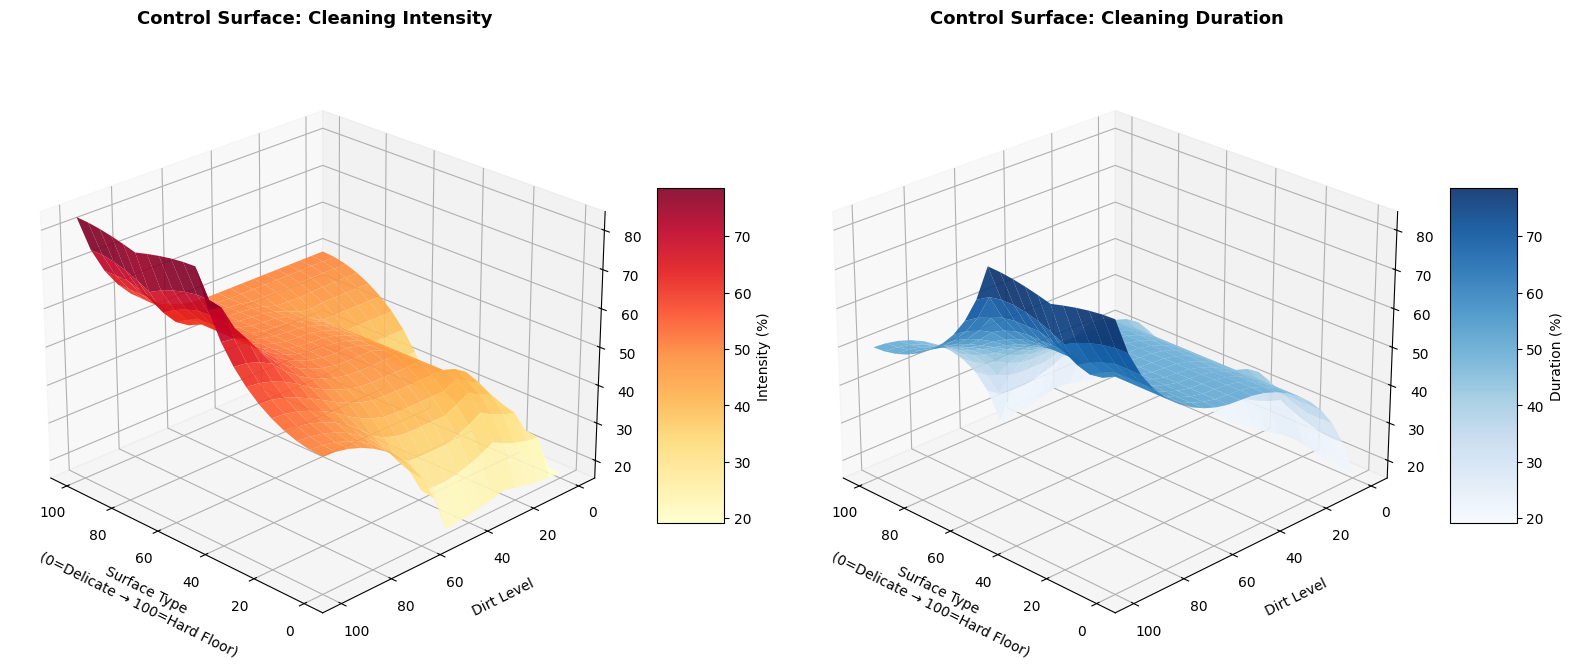

In [14]:
# 3D Surface Plots
from mpl_toolkits.mplot3d import Axes3D

X, Y = np.meshgrid(surface_range, dirt_range)

fig = plt.figure(figsize=(16, 7))

# Plot 1: Cleaning Intensity Surface
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, Y, intensity_surface, cmap='YlOrRd', alpha=0.9, edgecolor='none')
ax1.set_xlabel('Surface Type\n(0=Delicate → 100=Hard Floor)', fontsize=10, labelpad=10)
ax1.set_ylabel('Dirt Level', fontsize=10, labelpad=10)
ax1.set_zlabel('Cleaning Intensity', fontsize=10, labelpad=10)
ax1.set_title('Control Surface: Cleaning Intensity', fontsize=13, fontweight='bold', pad=20)
ax1.view_init(elev=25, azim=135)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5, label='Intensity (%)')

# Plot 2: Cleaning Duration Surface
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X, Y, duration_surface, cmap='Blues', alpha=0.9, edgecolor='none')
ax2.set_xlabel('Surface Type\n(0=Delicate → 100=Hard Floor)', fontsize=10, labelpad=10)
ax2.set_ylabel('Dirt Level', fontsize=10, labelpad=10)
ax2.set_zlabel('Cleaning Duration', fontsize=10, labelpad=10)
ax2.set_title('Control Surface: Cleaning Duration', fontsize=13, fontweight='bold', pad=20)
ax2.view_init(elev=25, azim=135)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5, label='Duration (%)')

plt.tight_layout()
plt.show()

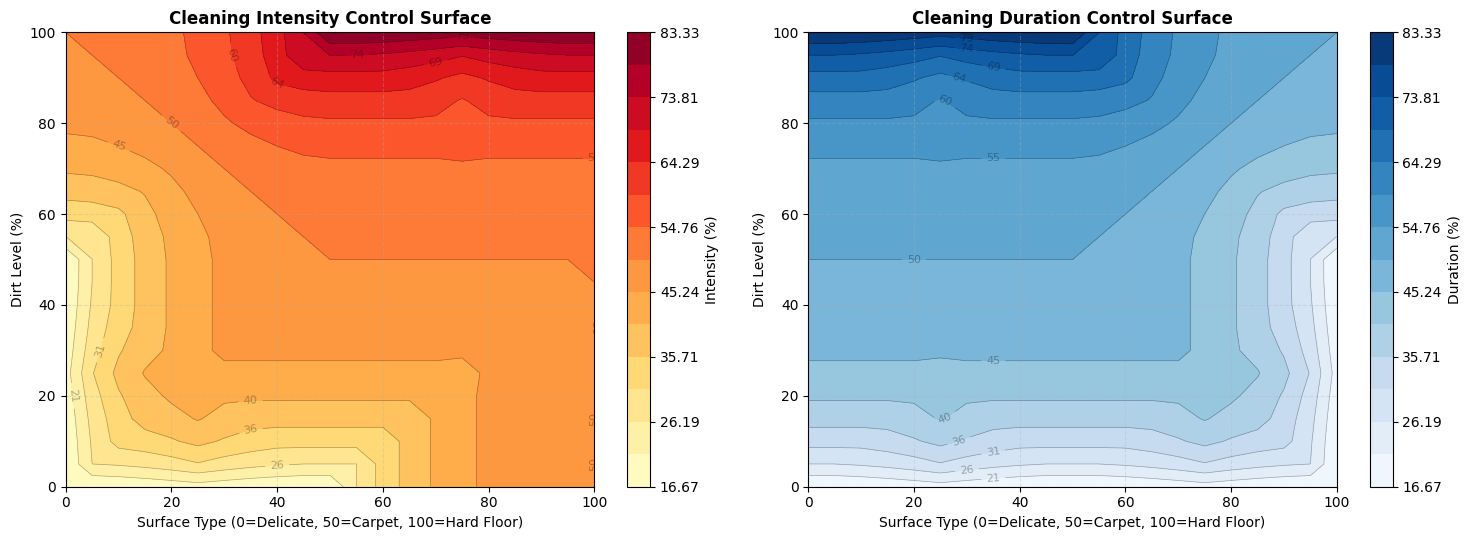

In [15]:
# 2D Contour plots for easier analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Contour 1: Intensity
levels_int = np.linspace(intensity_surface.min(), intensity_surface.max(), 15)
contour1 = ax1.contourf(X, Y, intensity_surface, levels=levels_int, cmap='YlOrRd')
contour1_lines = ax1.contour(X, Y, intensity_surface, levels=levels_int, colors='black', alpha=0.3, linewidths=0.5)
ax1.clabel(contour1_lines, inline=True, fontsize=8, fmt='%1.0f')
ax1.set_xlabel('Surface Type (0=Delicate, 50=Carpet, 100=Hard Floor)', fontsize=10)
ax1.set_ylabel('Dirt Level (%)', fontsize=10)
ax1.set_title('Cleaning Intensity Control Surface', fontsize=12, fontweight='bold')
fig.colorbar(contour1, ax=ax1, label='Intensity (%)')
ax1.grid(True, alpha=0.3, linestyle='--')

# Contour 2: Duration
levels_dur = np.linspace(duration_surface.min(), duration_surface.max(), 15)
contour2 = ax2.contourf(X, Y, duration_surface, levels=levels_dur, cmap='Blues')
contour2_lines = ax2.contour(X, Y, duration_surface, levels=levels_dur, colors='black', alpha=0.3, linewidths=0.5)
ax2.clabel(contour2_lines, inline=True, fontsize=8, fmt='%1.0f')
ax2.set_xlabel('Surface Type (0=Delicate, 50=Carpet, 100=Hard Floor)', fontsize=10)
ax2.set_ylabel('Dirt Level (%)', fontsize=10)
ax2.set_title('Cleaning Duration Control Surface', fontsize=12, fontweight='bold')
fig.colorbar(contour2, ax=ax2, label='Duration (%)')
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


## [Your after-class (additional) study]

A fuzzy inference system does not rely on rigid decision boundaries. Instead, it combines overlapping rules and membership functions to produce smooth and adaptive behaviour. This allows intelligent systems to operate effectively in environments where conditions are uncertain, imprecise, or continuously changing.

If you want to explore further:
* Try adding more inputs (battery level, time pressure)
* Experiment with different membership function shapes
